# YOLO: Detecção de Objetos

Nome: Gabriel Filipe da Silva Melo. Matrícula: Matrícula: 125.304-6

Treinamento e avaliação comparativa de modelos YOLO usando o ultralytics no dataset de detecção com 3 classes: **Car**, **Computer** e **Spoon**.

O dataset foi confeccionado para a matéria de tópicos avançados de aprendizado o link para o dataset é: https://drive.google.com/file/d/1y2y_fmparv069_XC78PBmsJjFbjq-d7G/view?usp=drive_link (adicionei o conjunto zipado no moodle).

Adicionei 3 tipos diferentes de export e uma versão com o train-test-split feito, com o nome detection_yolov8_128.

| Info | Valor |
|------|-------|
| Dataset | `detection_yolov8_128` |
| Imagens | 149 (128×128 px) |
| Classes | Car, Computer, Spoon |
| Split | Train 104 / Val 30 / Test 15 |

### Modelos que serão comparados

Escolhi modelos pequenos devido a limitação de tempo e hardware.

| Modelo | Versão | Tamanho | Params (aprox.) |
|--------|--------|---------|----------------|
| YOLOv8n | v8 | Nano | ~3.2M |
| YOLOv8s | v8 | Small | ~11.2M |
| YOLO11n | v11 | Nano | ~2.6M |
| YOLO11s | v11 | Small | ~9.4M |

In [1]:
from pathlib import Path
import yaml
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
from ultralytics import YOLO

print(f"PyTorch:  {torch.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:      {torch.cuda.get_device_name(0)}")

PyTorch:  2.13.0+cu130
CUDA:     True
GPU:      NVIDIA GeForce RTX 3060 Ti


In [5]:
# Caminhos do dataset
DATASET_DIR = Path("../datasets/detection_yolov8_128")
DATA_YAML = DATASET_DIR / "data.yaml"

assert DATA_YAML.exists(), f"data.yaml não encontrado em {DATA_YAML}"

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg["names"]
NUM_CLASSES = len(CLASS_NAMES)

print(f"Dataset:  {DATASET_DIR.resolve()}")
print(f"Classes:  {CLASS_NAMES}")
print(f"Splits:   train={data_cfg['train']}, val={data_cfg['val']}, test={data_cfg['test']}")

Dataset:  /home/melo/Projects/machine-learning/datasets/detection_yolov8_128
Classes:  {0: 'Car', 1: 'Computer', 2: 'Spoon'}
Splits:   train=train/images, val=val/images, test=test/images


In [6]:
# Definição dos modelos a treinar
MODELS = {
    "yolov8n": "yolov8n.pt",
    "yolov8s": "yolov8s.pt",
    "yolo11n": "yolo11n.pt",
    "yolo11s": "yolo11s.pt",
}

# Cores para cada modelo nos gráficos
MODEL_COLORS = {
    "yolov8n": "#2196F3",  # azul
    "yolov8s": "#1565C0",  # azul escuro
    "yolo11n": "#FF9800",  # laranja
    "yolo11s": "#E65100",  # laranja escuro
}

# Cores para as classes de detecção
CLASS_COLORS = {0: "#FF6B6B", 1: "#4ECDC4", 2: "#FFE66D"}  # Car, Computer, Spoon

# Hiperparâmetros compartilhados
TRAIN_CFG = dict(
    data=str(DATA_YAML.resolve()),
    epochs=100,
    imgsz=128,
    batch=16,
    patience=20,
    device=0,
    workers=4,
    exist_ok=True,
    verbose=True,
)

print(f"Modelos: {list(MODELS.keys())}")
print(f"Config:  epochs={TRAIN_CFG['epochs']}, imgsz={TRAIN_CFG['imgsz']}, batch={TRAIN_CFG['batch']}, patience={TRAIN_CFG['patience']}")

Modelos: ['yolov8n', 'yolov8s', 'yolo11n', 'yolo11s']
Config:  epochs=100, imgsz=128, batch=16, patience=20


### Exploração do Dataset

In [8]:
# Contagem de imagens e anotações por split
stats = {}
for split in ["train", "val", "test"]:
    img_dir = DATASET_DIR / split / "images"
    lbl_dir = DATASET_DIR / split / "labels"
    imgs = list(img_dir.glob("*.jpg"))
    
    class_counts = {i: 0 for i in range(NUM_CLASSES)}
    total_bboxes = 0
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = [l.strip() for l in lbl_file.read_text().splitlines() if l.strip()]
        total_bboxes += len(lines)
        for line in lines:
            cls_id = int(line.split()[0])
            class_counts[cls_id] += 1
    
    stats[split] = {
        "images": len(imgs),
        "bboxes": total_bboxes,
        "class_counts": class_counts,
    }
    print(f"{split:>5}: {len(imgs):>3} imgs, {total_bboxes:>3} bboxes  →  {class_counts}")

total_imgs = sum(s["images"] for s in stats.values())
total_bboxes = sum(s["bboxes"] for s in stats.values())
print(f"{'TOTAL':>5}: {total_imgs:>3} imgs, {total_bboxes:>3} bboxes")

train: 104 imgs, 155 bboxes  →  {0: 34, 1: 40, 2: 81}
  val:  30 imgs,  48 bboxes  →  {0: 13, 1: 10, 2: 25}
 test:  15 imgs,  23 bboxes  →  {0: 8, 1: 6, 2: 9}
TOTAL: 149 imgs, 226 bboxes


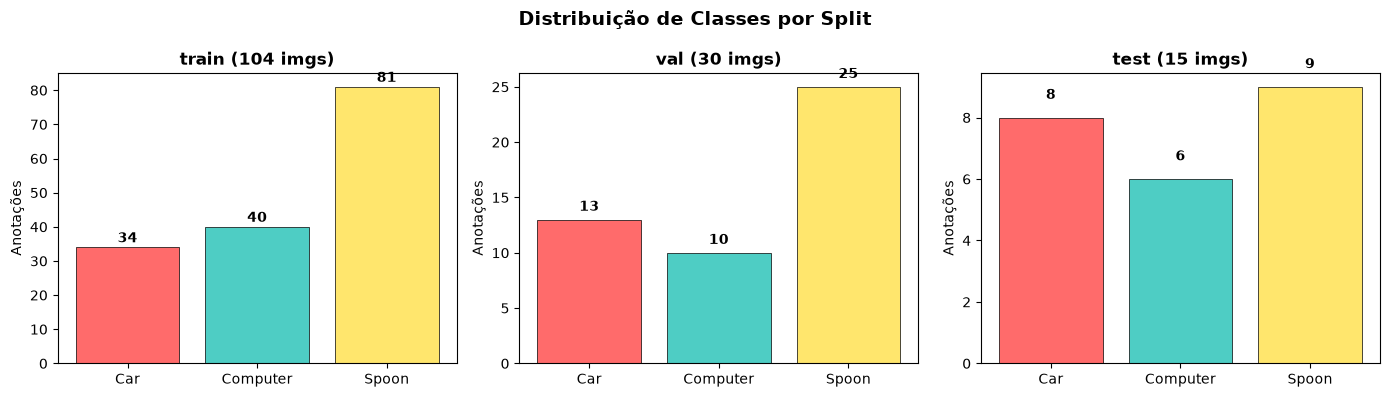

In [9]:
# Distribuição de classes por split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, split in zip(axes, ["train", "val", "test"]):
    counts = stats[split]["class_counts"]
    names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
    values = [counts[i] for i in range(NUM_CLASSES)]
    colors = [CLASS_COLORS[i] for i in range(NUM_CLASSES)]
    
    bars = ax.bar(names, values, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{split} ({stats[split]['images']} imgs)", fontweight="bold")
    ax.set_ylabel("Anotações")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(val), ha="center", va="bottom", fontweight="bold")

fig.suptitle("Distribuição de Classes por Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

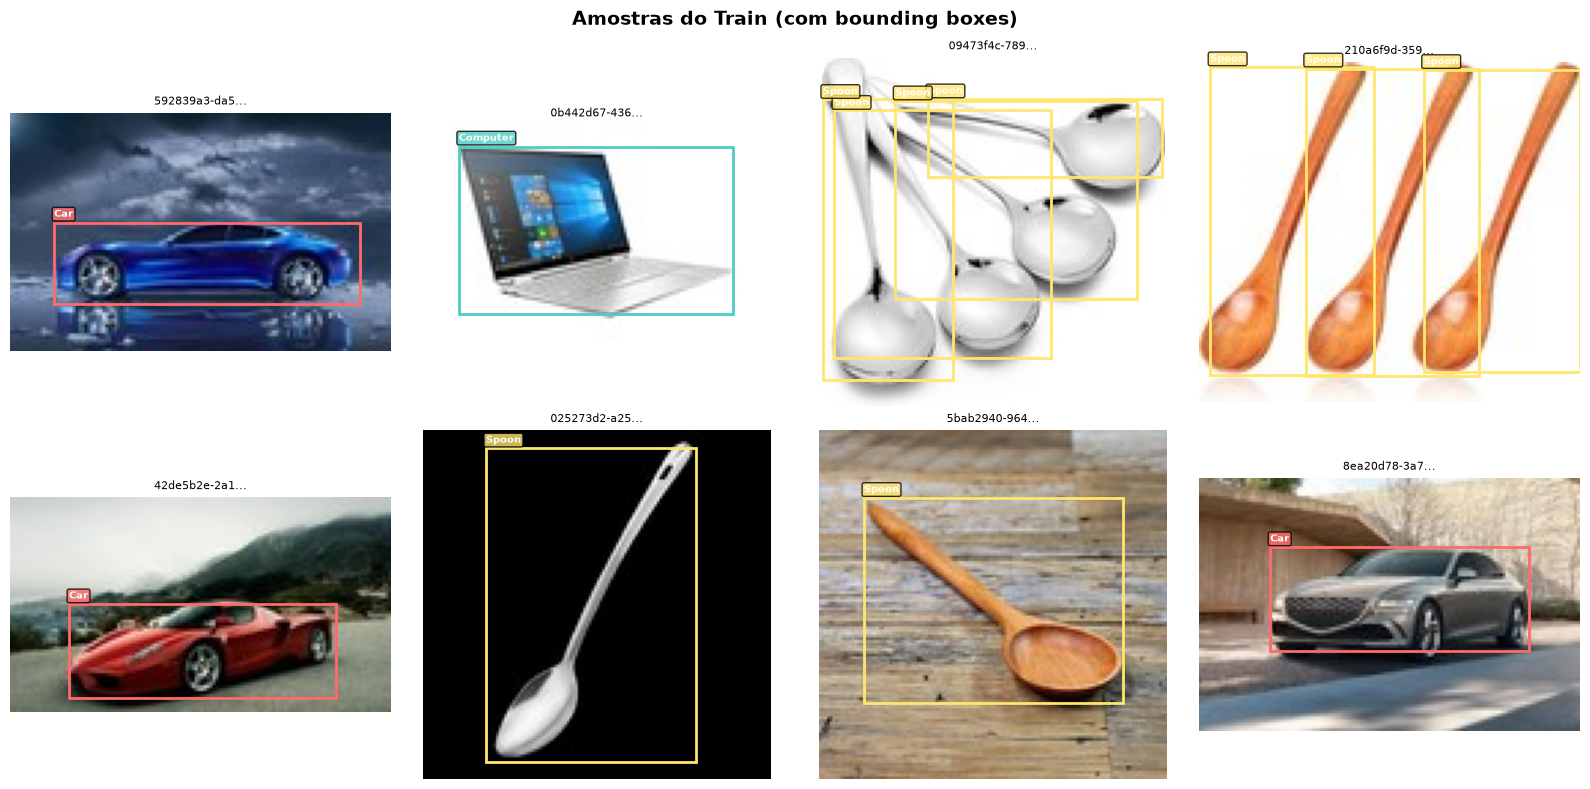

In [10]:
def plot_image_with_bboxes(img_path, lbl_path, class_names, colors, ax=None):
    """Plota uma imagem com suas bounding boxes YOLO."""
    img = Image.open(img_path)
    w, h = img.size
    
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4, 4))
    
    ax.imshow(img)
    
    if lbl_path.exists():
        lines = [l.strip() for l in lbl_path.read_text().splitlines() if l.strip()]
        for line in lines:
            parts = line.split()
            cls_id = int(parts[0])
            xc, yc, bw, bh = [float(x) for x in parts[1:5]]
            
            # Converter YOLO (normalizado, centro) → pixel (canto)
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            box_w = bw * w
            box_h = bh * h
            
            color = colors[cls_id]
            rect = patches.Rectangle((x1, y1), box_w, box_h,
                                     linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, class_names[cls_id],
                    color="white", fontsize=7, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.8))
    
    ax.set_title(img_path.stem[:12] + "...", fontsize=8)
    ax.axis("off")


# Visualizar amostras do train
train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))
sample_imgs = random.sample(train_imgs, min(8, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    lbl_path = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    plot_image_with_bboxes(img_path, lbl_path, CLASS_NAMES, CLASS_COLORS, ax=ax)

fig.suptitle("Amostras do Train (com bounding boxes)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Treinamento

Treina os 4 modelos sequencialmente com os mesmos hiperparâmetros, usando transfer learning dos pesos pré-treinados no COCO Dataset.

In [11]:
# Treinar todos os modelos
trained = {}  # {nome: {"model": YOLO, "train_dir": Path, "train_time": float, "params": int}}

for name, weights in MODELS.items():
    print(f"\n{'='*60}")
    print(f"  Treinando: {name} ({weights})")
    print(f"{'='*60}\n")
    
    model = YOLO(weights)
    n_params = sum(p.numel() for p in model.model.parameters())
    
    t0 = time.time()
    train_results = model.train(
        **TRAIN_CFG,
        project="runs",
        name=name,
    )
    train_time = time.time() - t0
    
    train_dir = Path(train_results.save_dir)
    
    trained[name] = {
        "model": model,
        "train_dir": train_dir,
        "train_time": train_time,
        "params": n_params,
    }
    
    print(f"\n✅ {name} concluído em {train_time:.1f}s — salvo em: {train_dir}")

print(f"\n{'='*60}")
print("Todos os modelos treinados!")
for name, info in trained.items():
    print(f"  {name:<10} — {info['params']:>10,} params — {info['train_time']:.1f}s")


  Treinando: yolov8n (yolov8n.pt)

New https://pypi.org/project/ultralytics/8.4.128 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.127 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7837MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/melo/Projects/machine-learning/datasets/detection_yolov8_128/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, iou=0.7, keras=Fa

### Comparativo de Treinamento

In [12]:
# Carregar métricas de todos os modelos
all_metrics = {}
for name, info in trained.items():
    csv_path = info["train_dir"] / "results.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        all_metrics[name] = df
    else:
        print(f"⚠️  results.csv não encontrado para {name}")

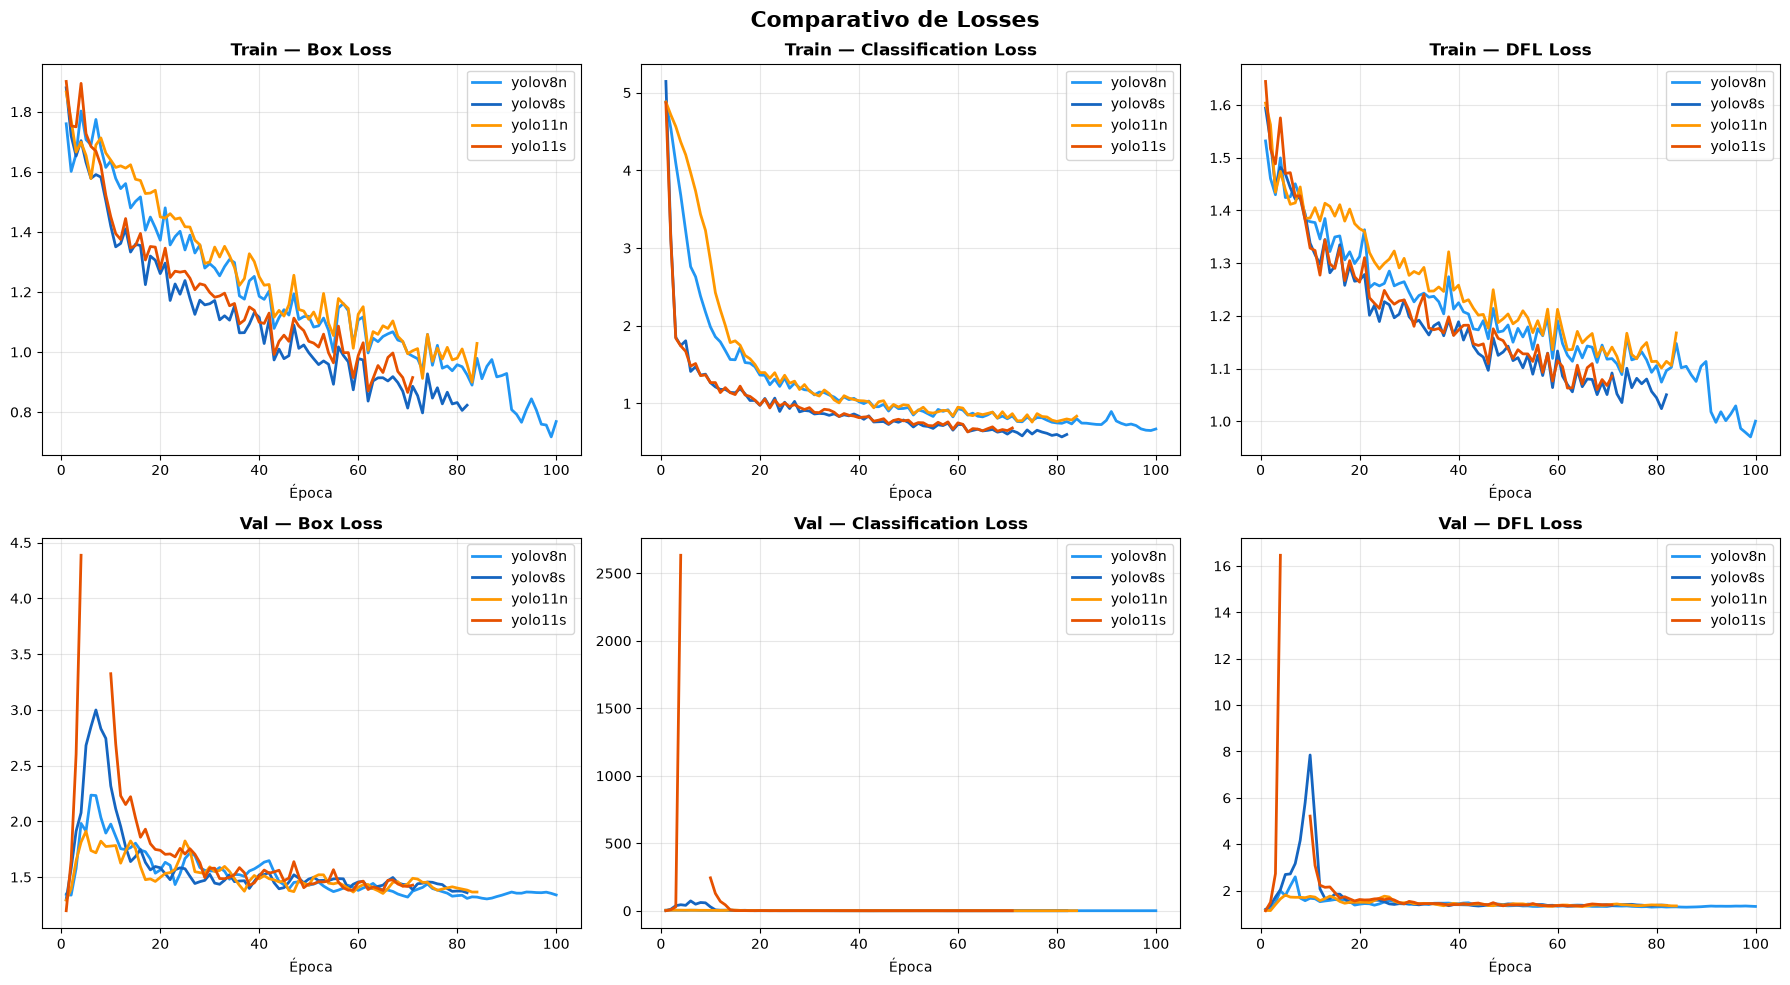

In [13]:
# Comparativo de losses
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

loss_cols = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Classification Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

# Linha 1: Train losses
for ax, (train_col, _, title) in zip(axes[0], loss_cols):
    for name, df in all_metrics.items():
        ax.plot(df["epoch"], df[train_col], label=name,
                color=MODEL_COLORS[name], linewidth=2)
    ax.set_title(f"Train — {title}", fontweight="bold")
    ax.set_xlabel("Época")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Linha 2: Val losses
for ax, (_, val_col, title) in zip(axes[1], loss_cols):
    for name, df in all_metrics.items():
        ax.plot(df["epoch"], df[val_col], label=name,
                color=MODEL_COLORS[name], linewidth=2)
    ax.set_title(f"Val — {title}", fontweight="bold")
    ax.set_xlabel("Época")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Comparativo de Losses", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

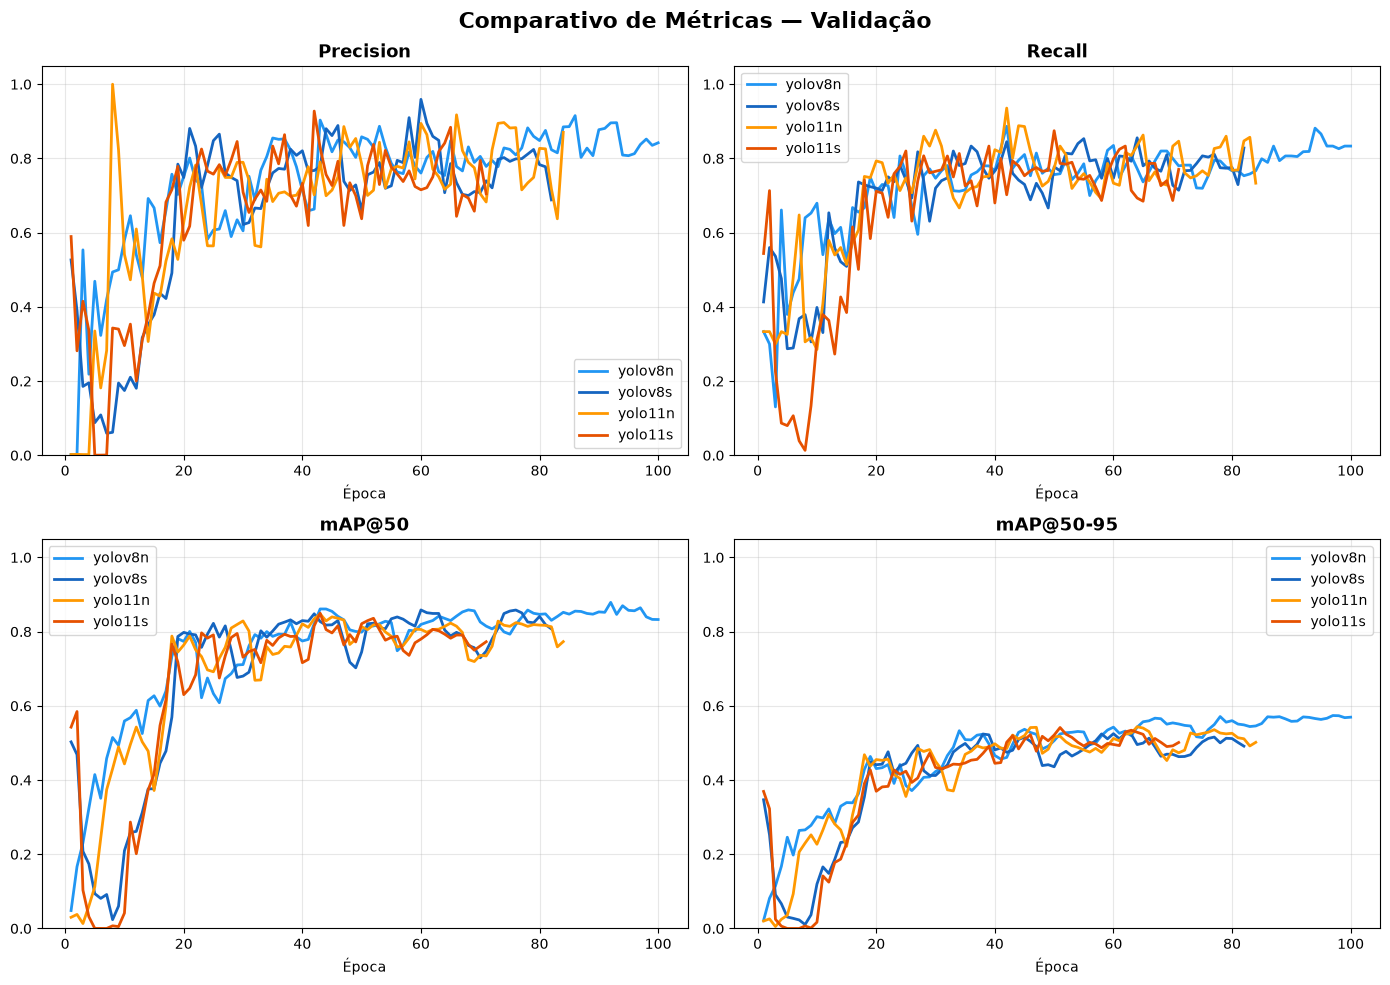

In [14]:
# Comparativo de métricas de desempenho
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metric_cols = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP@50"),
    ("metrics/mAP50-95(B)", "mAP@50-95"),
]

for ax, (col, title) in zip(axes.flat, metric_cols):
    for name, df in all_metrics.items():
        ax.plot(df["epoch"], df[col], label=name,
                color=MODEL_COLORS[name], linewidth=2)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xlabel("Época")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Comparativo de Métricas — Validação", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [15]:
# Tabela: melhor mAP@50 de cada modelo durante o treino
print(f"{'Modelo':<12} {'Melhor Época':>12} {'mAP@50':>10} {'mAP@50-95':>12} {'Precision':>10} {'Recall':>10}")
print("-" * 68)
for name, df in all_metrics.items():
    best_idx = df["metrics/mAP50(B)"].idxmax()
    row = df.loc[best_idx]
    print(f"{name:<12} {int(row['epoch']):>12} {row['metrics/mAP50(B)']:>10.4f} "
          f"{row['metrics/mAP50-95(B)']:>12.4f} {row['metrics/precision(B)']:>10.4f} "
          f"{row['metrics/recall(B)']:>10.4f}")

Modelo       Melhor Época     mAP@50    mAP@50-95  Precision     Recall
--------------------------------------------------------------------
yolov8n                92     0.8788       0.5702     0.8959     0.8182
yolov8s                60     0.8584       0.5250     0.9592     0.7467
yolo11n                43     0.8479       0.5212     0.7904     0.8005
yolo11s                43     0.8497       0.5199     0.8290     0.7933


### Avaliação no Conjunto de Validação

In [16]:
# Carregar os melhores modelos e avaliar no val
val_results = {}

for name, info in trained.items():
    best_pt = info["train_dir"] / "weights" / "best.pt"
    best_model = YOLO(best_pt)
    
    val_metrics = best_model.val(
        data=str(DATA_YAML.resolve()),
        split="val",
        imgsz=128,
        device=0,
        verbose=False,
    )
    
    val_results[name] = {
        "best_model": best_model,
        "metrics": val_metrics,
    }

# Tabela comparativa
print("=" * 70)
print("MÉTRICAS DE VALIDAÇÃO — COMPARATIVO")
print("=" * 70)
print(f"{'Modelo':<12} {'mAP@50':>10} {'mAP@50-95':>12} {'Precision':>10} {'Recall':>10}")
print("-" * 56)
for name, res in val_results.items():
    m = res["metrics"]
    print(f"{name:<12} {m.box.map50:>10.4f} {m.box.map:>12.4f} {m.box.mp:>10.4f} {m.box.mr:>10.4f}")

Ultralytics 8.4.127 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7837MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 975.2±416.6 MB/s, size: 5.4 KB)
val: Scanning /home/melo/Projects/machine-learning/datasets/detection_yolov8_128/val/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 31.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 13.6it/s 0.1s
                   all         30         48      0.836      0.833      0.866      0.572
Speed: 0.3ms preprocess, 3.3ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/melo/Projects/machine-learning/runs/detect/val-19
Ultralytics 8.4.127 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7837MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast

In [17]:
# Métricas por classe — cada modelo
for name, res in val_results.items():
    m = res["metrics"]
    print(f"\n{'─'*50}")
    print(f"  {name} — Métricas por classe (Val)")
    print(f"{'─'*50}")
    print(f"{'Classe':<12} {'mAP@50':>10} {'mAP@50-95':>12} {'P':>8} {'R':>8}")
    print("-" * 50)
    for i, cls_name in CLASS_NAMES.items():
        ap50 = m.box.ap50[i] if i < len(m.box.ap50) else 0
        ap = m.box.ap[i] if i < len(m.box.ap) else 0
        p = m.box.p[i] if i < len(m.box.p) else 0
        r = m.box.r[i] if i < len(m.box.r) else 0
        print(f"{cls_name:<12} {ap50:>10.4f} {ap:>12.4f} {p:>8.4f} {r:>8.4f}")


──────────────────────────────────────────────────
  yolov8n — Métricas por classe (Val)
──────────────────────────────────────────────────
Classe           mAP@50    mAP@50-95        P        R
--------------------------------------------------
Car              0.9736       0.7781   0.9269   1.0000
Computer         0.9683       0.6404   0.8890   0.9000
Spoon            0.6559       0.2966   0.6931   0.6000

──────────────────────────────────────────────────
  yolov8s — Métricas por classe (Val)
──────────────────────────────────────────────────
Classe           mAP@50    mAP@50-95        P        R
--------------------------------------------------
Car              0.9843       0.7569   0.9087   1.0000
Computer         0.9038       0.5148   0.7431   0.8696
Spoon            0.6350       0.2889   0.9071   0.5200

──────────────────────────────────────────────────
  yolo11n — Métricas por classe (Val)
──────────────────────────────────────────────────
Classe           mAP@50    mAP@50-9

## Avaliação no Conjunto de Teste

In [18]:
# Avaliar todos os modelos no test
test_results = {}

for name, res in val_results.items():
    test_metrics = res["best_model"].val(
        data=str(DATA_YAML.resolve()),
        split="test",
        imgsz=128,
        device=0,
        verbose=False,
    )
    test_results[name] = test_metrics

print("=" * 70)
print("MÉTRICAS DE TESTE — COMPARATIVO")
print("=" * 70)
print(f"{'Modelo':<12} {'mAP@50':>10} {'mAP@50-95':>12} {'Precision':>10} {'Recall':>10}")
print("-" * 56)
for name, m in test_results.items():
    print(f"{name:<12} {m.box.map50:>10.4f} {m.box.map:>12.4f} {m.box.mp:>10.4f} {m.box.mr:>10.4f}")

Ultralytics 8.4.127 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7837MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 655.5±182.5 MB/s, size: 3.5 KB)
val: Scanning /home/melo/Projects/machine-learning/datasets/detection_yolov8_128/test/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 19.2it/s 0.1s
                   all         15         23      0.849      0.706      0.798      0.608
Speed: 0.0ms preprocess, 2.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/melo/Projects/machine-learning/runs/detect/val-23
Ultralytics 8.4.127 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7837MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 653.2±482.8 MB/s, size: 3.5 KB)
val: Scanning /home/melo/Projects/machine-learning/datasets/detection_yolov8_128/test/la

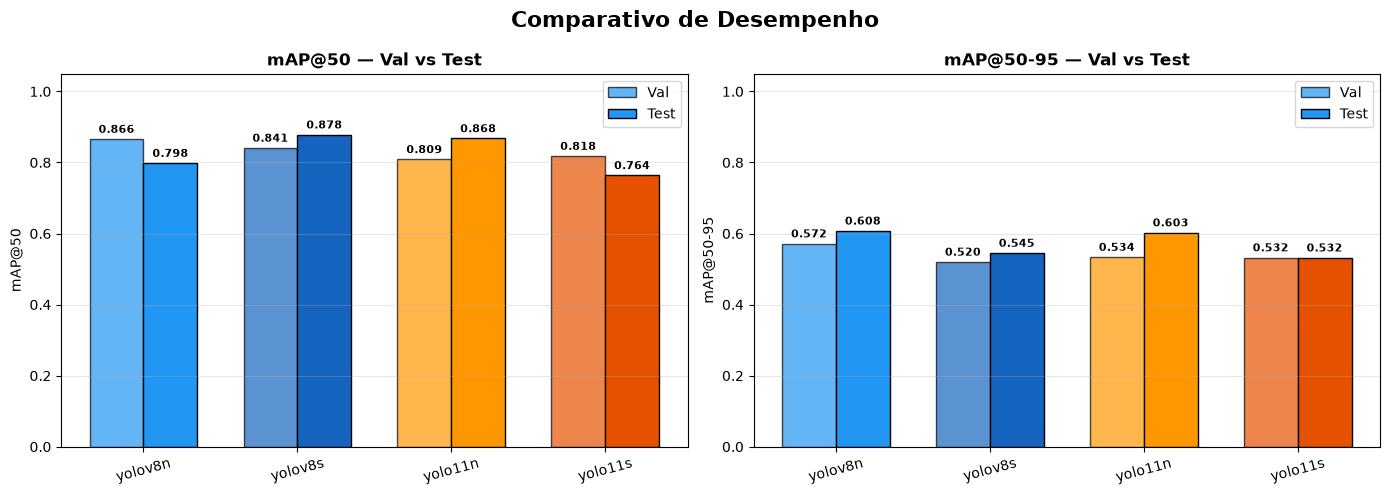

In [19]:
# Gráfico comparativo: Val vs Test mAP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(val_results.keys())
x = np.arange(len(model_names))
bar_colors = [MODEL_COLORS[n] for n in model_names]

# mAP@50
val_map50 = [val_results[n]["metrics"].box.map50 for n in model_names]
test_map50 = [test_results[n].box.map50 for n in model_names]

w = 0.35
bars1 = axes[0].bar(x - w/2, val_map50, w, label="Val", color=bar_colors, alpha=0.7, edgecolor="black")
bars2 = axes[0].bar(x + w/2, test_map50, w, label="Test", color=bar_colors, alpha=1.0, edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel("mAP@50")
axes[0].set_title("mAP@50 — Val vs Test", fontweight="bold")
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis="y")
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# mAP@50-95
val_map = [val_results[n]["metrics"].box.map for n in model_names]
test_map = [test_results[n].box.map for n in model_names]

bars1 = axes[1].bar(x - w/2, val_map, w, label="Val", color=bar_colors, alpha=0.7, edgecolor="black")
bars2 = axes[1].bar(x + w/2, test_map, w, label="Test", color=bar_colors, alpha=1.0, edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel("mAP@50-95")
axes[1].set_title("mAP@50-95 — Val vs Test", fontweight="bold")
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis="y")
for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

fig.suptitle("Comparativo de Desempenho", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Matrizes de Confusão

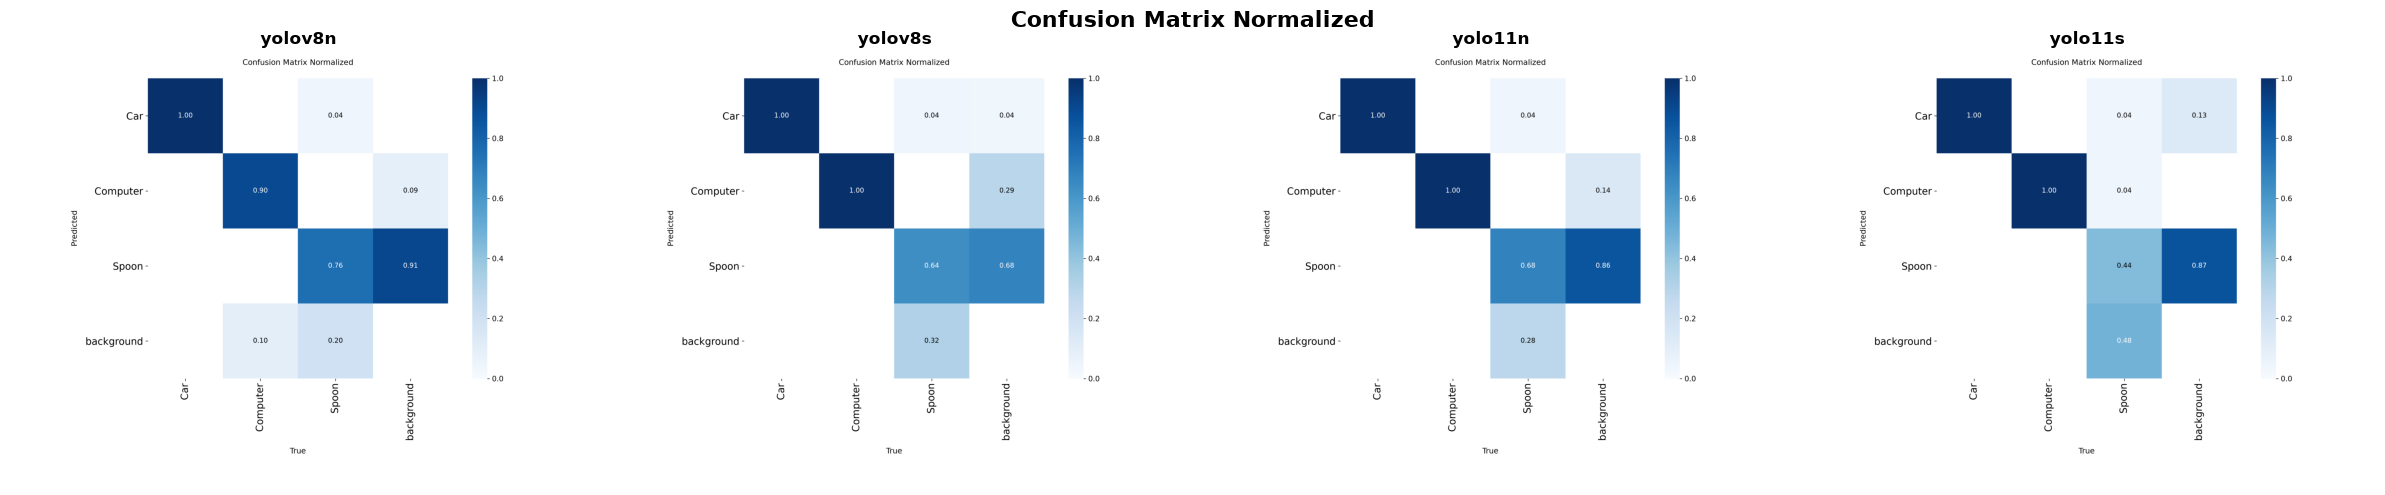

In [20]:
# Exibir confusion matrix e PR curve de cada modelo
key_plots = ["confusion_matrix_normalized.png", "PR_curve.png"]

for plot_name in key_plots:
    available_models = [n for n in trained if (trained[n]["train_dir"] / plot_name).exists()]
    
    if not available_models:
        continue
    
    n_models = len(available_models)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    if n_models == 1:
        axes = [axes]
    
    for ax, name in zip(axes, available_models):
        img = Image.open(trained[name]["train_dir"] / plot_name)
        ax.imshow(img)
        ax.set_title(name, fontweight="bold", fontsize=12)
        ax.axis("off")
    
    title = plot_name.replace("_", " ").replace(".png", "").title()
    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Inferência Comparativa no Teste

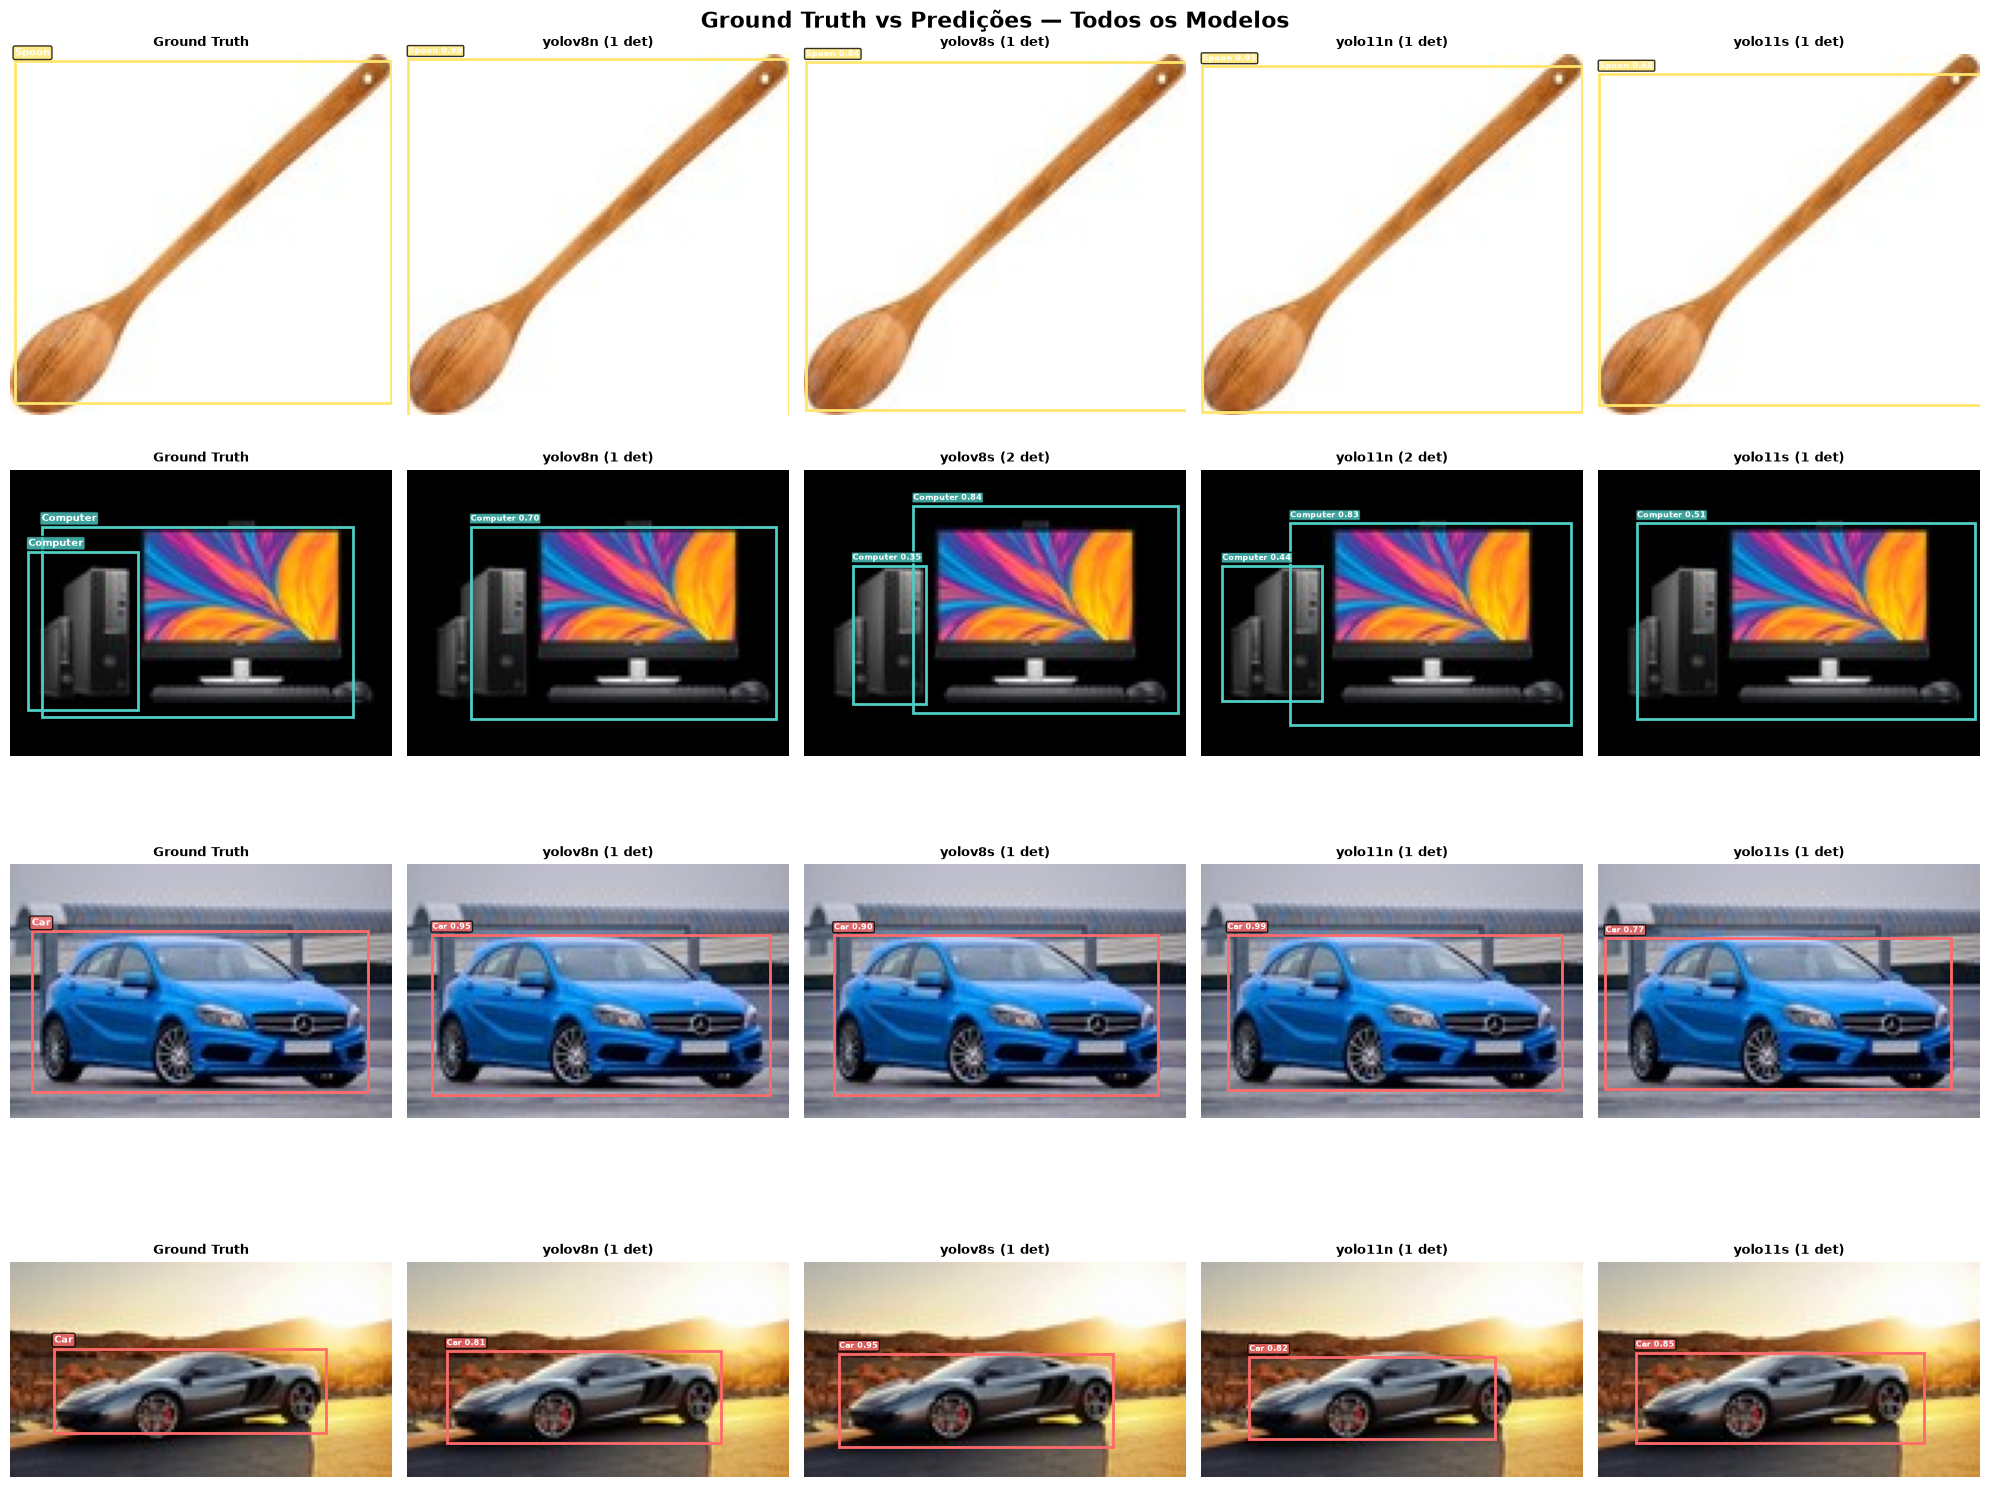

In [21]:
def draw_predictions(ax, img_path, model, class_names, class_colors, title=""):
    """Desenha as predições de um modelo em uma imagem."""
    preds = model.predict(str(img_path), imgsz=128, conf=0.25, device=0, verbose=False)
    result = preds[0]
    
    img = Image.open(img_path)
    ax.imshow(img)
    
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        color = class_colors[cls_id]
        
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, f"{class_names[cls_id]} {conf:.2f}",
                color="white", fontsize=6, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", facecolor=color, alpha=0.8))
    
    ax.set_title(f"{title} ({len(result.boxes)} det)", fontsize=9, fontweight="bold")
    ax.axis("off")


# Comparar predições de todos os modelos lado a lado
test_imgs = sorted((DATASET_DIR / "test" / "images").glob("*.jpg"))
sample_test = random.sample(test_imgs, min(4, len(test_imgs)))
n_models = len(val_results)

fig, axes = plt.subplots(len(sample_test), n_models + 1, figsize=(4 * (n_models + 1), 4 * len(sample_test)))

for row, img_path in enumerate(sample_test):
    # Coluna 0: Ground Truth
    lbl_path = DATASET_DIR / "test" / "labels" / (img_path.stem + ".txt")
    plot_image_with_bboxes(img_path, lbl_path, CLASS_NAMES, CLASS_COLORS, ax=axes[row, 0])
    axes[row, 0].set_title("Ground Truth", fontsize=9, fontweight="bold")
    
    # Colunas 1+: Predição de cada modelo
    for col, (name, res) in enumerate(val_results.items(), 1):
        draw_predictions(axes[row, col], img_path, res["best_model"],
                         CLASS_NAMES, CLASS_COLORS, title=name)

fig.suptitle("Ground Truth vs Predições — Todos os Modelos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Resumo por Modelo

In [22]:
# Tabela resumo com todas as informações
summary_data = []
for name in trained:
    info = trained[name]
    val_m = val_results[name]["metrics"]
    test_m = test_results[name]
    
    summary_data.append({
        "Modelo": name,
        "Versão": "v8" if "v8" in name else "v11",
        "Tamanho": "Nano" if "n" in name[-1] else "Small",
        "Params": f"{info['params']:,}",
        "Tempo (s)": f"{info['train_time']:.1f}",
        "Val mAP@50": f"{val_m.box.map50:.4f}",
        "Val mAP@50-95": f"{val_m.box.map:.4f}",
        "Test mAP@50": f"{test_m.box.map50:.4f}",
        "Test mAP@50-95": f"{test_m.box.map:.4f}",
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("COMPARATIVO DE MODELOS")
print("=" * 100)
print(summary_df.to_string(index=False))


COMPARATIVO DE MODELOS
 Modelo Versão Tamanho     Params Tempo (s) Val mAP@50 Val mAP@50-95 Test mAP@50 Test mAP@50-95
yolov8n     v8    Nano  3,157,200      35.0     0.8659        0.5717      0.7983         0.6077
yolov8s     v8   Small 11,166,560      36.3     0.8410        0.5202      0.8782         0.5452
yolo11n    v11    Nano  2,624,080      35.4     0.8089        0.5338      0.8677         0.6026
yolo11s    v11   Small  9,458,752      35.2     0.8180        0.5324      0.7639         0.5320
